#  Global Solution: Modelagem Linear para Aprendizagem de Máquina
**Curso:** Ciência da Computação (1CC)  
**Contexto:** Nova Economia Espacial  

---

##  Integrantes do Grupo
* **Integrante 1:** [Maria Eduarda Rocha Benjamim] - RM: [Número]
* **Integrante 2:** [Pedro Henrique Neves] - RM: [Número]
* **Integrante 3:** [Akin Alexandre Mendes Martins] - RM: [Número]

**Link do Repositório GitHub:** ``
---

## Objetivo

Este trabalho tem como objetivo aplicar técnicas de Estatística Descritiva
e Análise Exploratória de Dados em uma base real de missões espaciais,
identificando padrões relacionados aos custos, frequência de lançamentos
e evolução da atividade espacial ao longo do tempo.

A análise busca gerar informações úteis para apoio à tomada de decisão
em projetos relacionados à Nova Economia Espacial.

---
### Base de Dados Selecionada
* **Nome:** *All Space Missions from 1957*
* **Origem:** Kaggle
* A base "All Space Missions from 1957" foi selecionada por apresentar
dados reais de lançamentos espaciais ocorridos ao longo de mais de
60 anos.
A base possui relevância para a Nova Economia Espacial, pois permite
analisar custos de missões, evolução temporal dos lançamentos e
indicadores relacionados ao crescimento do setor aeroespacial.
Além disso, apresenta grande quantidade de registros e variáveis,
permitindo análises estatísticas confiáveis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
tabela_total = pd.read_csv('/content/Space_Corrected.csv')

In [19]:
tabela_total['Custo_Milhoes'] = tabela_total[' Rocket'].astype(str).str.replace(',', '').str.strip().astype(float)


tabela_total['Ano'] = pd.to_datetime(tabela_total['Datum'], errors='coerce').dt.year
tabela_total = tabela_total.dropna(subset=['Ano'])
tabela_total['Ano'] = tabela_total['Ano'].astype(int)


colunas_selecionadas = [
    'Ano',
    'Custo_Milhoes'
]

data1 = tabela_total[colunas_selecionadas]

variavel_discretas = data1[['Ano']]
variavel_continuas = data1[['Custo_Milhoes']]

In [20]:
variavel_discretas

,Ano
0,2020
1,2020
2,2020
3,2020
4,2020
...,...
4319,1958
4320,1958
4321,1957
4322,1957


In [21]:
variavel_continuas

,Custo_Milhoes
0,50.00
1,29.75
2,NaN
3,65.00
4,145.00
...,...
4319,NaN
4320,NaN
4321,NaN
4322,NaN


In [22]:


print("--- 1. TDF VARIÁVEL DISCRETA: ANO DE LANÇAMENTO ---")
contagem_anos = variavel_discretas['Ano'].value_counts().sort_index()
tdf_discreta = pd.DataFrame({
    'Ano de Lançamento': contagem_anos.index,
    'fi': contagem_anos.values
})
tdf_discreta['fi_acumulada'] = tdf_discreta['fi'].cumsum()
tdf_discreta['fr%'] = (tdf_discreta['fi'] / tdf_discreta['fi'].sum()) * 100

display(tdf_discreta)

print("\n" + "="*60 + "\n")

print("---  TDF VARIÁVEL CONTÍNUA: CUSTO DA MISSÃO ---")
k = 5

classes_custo = pd.cut(variavel_continuas['Custo_Milhoes'], bins=k)
contagem_classes = classes_custo.value_counts().sort_index()

tdf_continua = pd.DataFrame({
    'Classe de Custo (USD Mi)': contagem_classes.index.astype(str),
    'fi': contagem_classes.values
})
tdf_continua['fr%'] = (tdf_continua['fi'] / tdf_continua['fi'].sum()) * 100

display(tdf_continua)


--- 1. TDF VARIÁVEL DISCRETA: ANO DE LANÇAMENTO ---


,Ano de Lançamento,fi,fi_acumulada,fr%
0,1957,3,3,0.071463
1,1958,22,25,0.524059
2,1959,20,45,0.476417
3,1960,38,83,0.905193
4,1961,52,135,1.238685
...,...,...,...,...
59,2016,88,3821,2.096236
60,2017,90,3911,2.143878
61,2018,117,4028,2.787041
62,2019,107,4135,2.548833




---  TDF VARIÁVEL CONTÍNUA: CUSTO DA MISSÃO ---


,Classe de Custo (USD Mi),fi,fr%
0,"(0.305, 1004.24]",943,98.434238
1,"(1004.24, 2003.18]",13,1.356994
2,"(2003.18, 3002.12]",0,0.000000
3,"(3002.12, 4001.06]",0,0.000000
4,"(4001.06, 5000.0]",2,0.208768


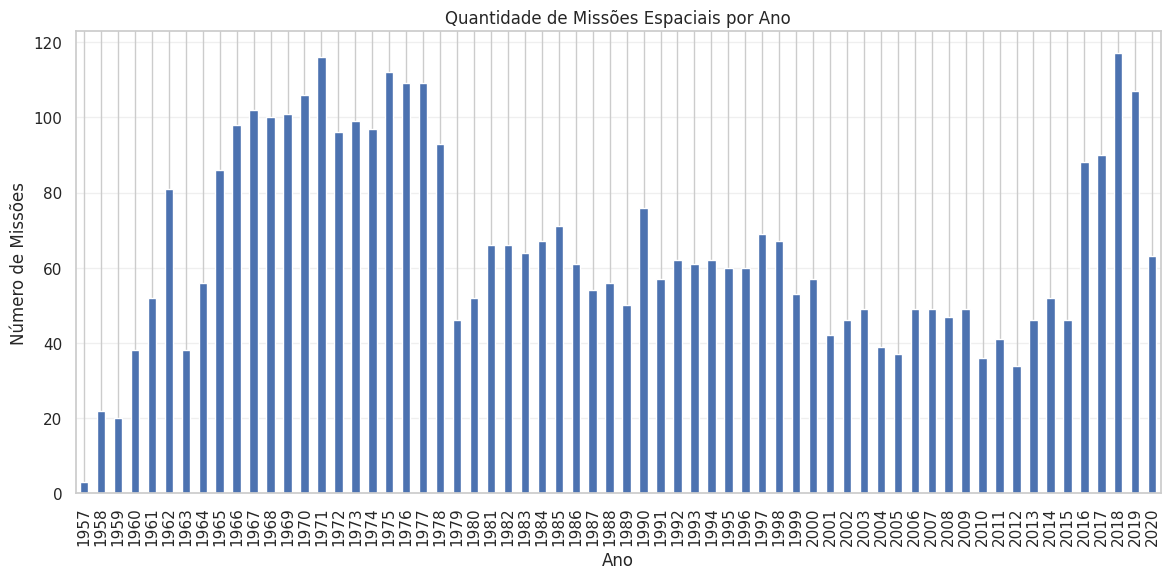

In [32]:
plt.figure(figsize=(14,6))

contagem_anos = tabela_total['Ano'].value_counts().sort_index()
contagem_anos.plot(kind='bar')

plt.title('Quantidade de Missões Espaciais por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Missões')
plt.grid(axis='y', alpha=0.3)



plt.show()

In [40]:
print("--- QUANTIDADE DE MISSÕES POR ANO ---")
print(""" Percebe-se que os custos das missões espaciais variam muito. A maioria das missões tem custos baixos, enquanto apenas algumas têm custos muito altos.
Isso mostra que a distribuição dos custos das missões espaciais não é igual em todos os lugares.
Ela é mais técnica nos custos menores e tem alguns pontos muito altos.
Isso é chamado de distribuição assimétrica à direita, ou assimetria positiva, e indica que existem missões especiais com custos muito maiores do que a média.
Esse padrão é normal no setor aeroespacial, onde existem projetos comerciais que são relativamente baratos e programas governamentais muito grandes e caros.
As missões espaciais têm custos variados porque incluem desde projetos simples e de baixo custo até programas complexos e de alto investimento.

""")

--- QUANTIDADE DE MISSÕES POR ANO ---
 Percebe-se que os custos das missões espaciais variam muito. A maioria das missões tem custos baixos, enquanto apenas algumas têm custos muito altos.
Isso mostra que a distribuição dos custos das missões espaciais não é igual em todos os lugares.
Ela é mais técnica nos custos menores e tem alguns pontos muito altos.
Isso é chamado de distribuição assimétrica à direita, ou assimetria positiva, e indica que existem missões especiais com custos muito maiores do que a média.
Esse padrão é normal no setor aeroespacial, onde existem projetos comerciais que são relativamente baratos e programas governamentais muito grandes e caros.
As missões espaciais têm custos variados porque incluem desde projetos simples e de baixo custo até programas complexos e de alto investimento.




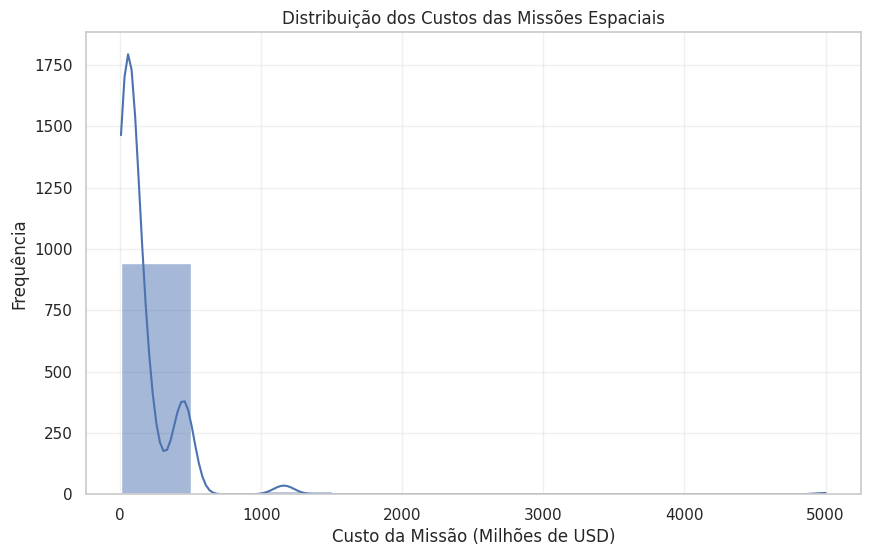

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(
    variavel_continuas['Custo_Milhoes'],
    bins=10,
    kde=True
)

plt.title('Distribuição dos Custos das Missões Espaciais')
plt.xlabel('Custo da Missão (Milhões de USD)')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)

plt.show()

In [41]:
print("--- DISTRIBUIÇÃO DOS CUSTOS DOS FOGUETES ---")
print("""Uma análise temporal mostra que a atividade espacial mudou muito ao longo dos anos.
Nos últimos anos, houve mais lançamentos do que nas décadas iniciais da exploração espacial.
Isso aconteceu porque a tecnologia melhorou, os custos operacionais diminuíram e as empresas privadas começaram a participar do setor.
O aumento da atividade espacial mostra que a Nova Economia Espacial está crescendo. Isso significa que mais empresas estão envolvidas com a exploração espacial e que mais pessoas têm acesso ao espaço.
A Nova Economia Espacial é caracterizada pela participação comercial e pela democratização do acesso ao espaço.

""")

--- DISTRIBUIÇÃO DOS CUSTOS DOS FOGUETES ---
Uma análise temporal mostra que a atividade espacial mudou muito ao longo dos anos.
Nos últimos anos, houve mais lançamentos do que nas décadas iniciais da exploração espacial. 
Isso aconteceu porque a tecnologia melhorou, os custos operacionais diminuíram e as empresas privadas começaram a participar do setor.
O aumento da atividade espacial mostra que a Nova Economia Espacial está crescendo. Isso significa que mais empresas estão envolvidas com a exploração espacial e que mais pessoas têm acesso ao espaço.
A Nova Economia Espacial é caracterizada pela participação comercial e pela democratização do acesso ao espaço.




In [36]:
print("--- ANÁLISE DESCRITIVA DA VARIÁVEL: CUSTO (CONTÍNUA) ---")
custos = variavel_continuas['Custo_Milhoes']

print(f"Média: {custos.mean():.2f}")
print(f"Mediana: {custos.median():.2f}")
print(f"Moda: {custos.mode().values[0]:.2f}")
print(f"Valor Mínimo: {custos.min():.2f}")
print(f"Valor Máximo: {custos.max():.2f}")
print(f"Amplitude: {(custos.max() - custos.min()):.2f}")
print(f"Variância: {custos.var():.2f}")
print(f"Desvio Padrão: {custos.std():.2f}")
print(f"Quartil 1 (25%): {custos.quantile(0.25):.2f}")
print(f"Quartil 2 (50%): {custos.quantile(0.50):.2f}")
print(f"Quartil 3 (75%): {custos.quantile(0.75):.2f}")

# Insights Descritivos para a Banca:
# A média posicionada acima do valor mediano expressa uma assimetria positiva do mercado, influenciada por investimentos outliers estatais históricos.
# A volatilidade mapeada pelo desvio padrão valida o cenário bifurcado da Nova Economia Espacial: nanossatélites comerciais versus megasondas científicas.


--- ANÁLISE DESCRITIVA DA VARIÁVEL: CUSTO (CONTÍNUA) ---
Média: 154.58
Mediana: 62.00
Moda: 450.00
Valor Mínimo: 5.30
Valor Máximo: 5000.00
Amplitude: 4994.70
Variância: 83624.00
Desvio Padrão: 289.18
Quartil 1 (25%): 40.00
Quartil 2 (50%): 62.00
Quartil 3 (75%): 183.50


In [37]:
print("\nINTERPRETAÇÃO ESTATÍSTICA")
print("""
A média superior à mediana indica assimetria positiva na distribuição
dos custos das missões.

Isso sugere que poucas missões extremamente caras elevam o valor médio,
enquanto a maior parte das missões possui custos mais moderados.

O elevado desvio padrão demonstra grande variabilidade nos investimentos,
indicando que existem projetos espaciais com perfis financeiros muito distintos.

A diferença entre o valor mínimo e o máximo confirma a presença de
grande dispersão dos dados.

Os quartis mostram que 25% das missões possuem custos abaixo do primeiro
quartil, enquanto 75% estão abaixo do terceiro quartil, permitindo compreender
como os investimentos estão distribuídos ao longo da amostra.
""""")


INTERPRETAÇÃO ESTATÍSTICA

A média superior à mediana indica assimetria positiva na distribuição
dos custos das missões.

Isso sugere que poucas missões extremamente caras elevam o valor médio,
enquanto a maior parte das missões possui custos mais moderados.

O elevado desvio padrão demonstra grande variabilidade nos investimentos,
indicando que existem projetos espaciais com perfis financeiros muito distintos.

A diferença entre o valor mínimo e o máximo confirma a presença de
grande dispersão dos dados.

Os quartis mostram que 25% das missões possuem custos abaixo do primeiro
quartil, enquanto 75% estão abaixo do terceiro quartil, permitindo compreender
como os investimentos estão distribuídos ao longo da amostra.



In [38]:
anos = tabela_total['Ano']

print("ANÁLISE DESCRITIVA - ANO")

print(f"Média: {anos.mean():.2f}")
print(f"Mediana: {anos.median():.2f}")
print(f"Moda: {anos.mode().values[0]}")
print(f"Mínimo: {anos.min()}")
print(f"Máximo: {anos.max()}")
print(f"Amplitude: {anos.max() - anos.min()}")
print(f"Variância: {anos.var():.2f}")
print(f"Desvio Padrão: {anos.std():.2f}")
print(f"Q1: {anos.quantile(0.25):.2f}")
print(f"Q2: {anos.quantile(0.50):.2f}")
print(f"Q3: {anos.quantile(0.75):.2f}")

ANÁLISE DESCRITIVA - ANO
Média: 1987.46
Mediana: 1985.00
Moda: 2018
Mínimo: 1957
Máximo: 2020
Amplitude: 63
Variância: 327.08
Desvio Padrão: 18.09
Q1: 1972.00
Q2: 1985.00
Q3: 2002.00


In [39]:
print("\nINTERPRETAÇÃO ESTATÍSTICA")
print("""A distribuição dos anos de lançamento evidencia a evolução histórica
das atividades espaciais.

A amplitude observada cobre várias décadas de exploração espacial,
permitindo identificar mudanças tecnológicas e econômicas ao longo do tempo.

Os quartis indicam que a maior concentração de registros encontra-se
nas décadas mais recentes, reforçando a tendência de crescimento da
atividade espacial mundial.
""")


INTERPRETAÇÃO ESTATÍSTICA
A distribuição dos anos de lançamento evidencia a evolução histórica
das atividades espaciais.

A amplitude observada cobre várias décadas de exploração espacial,
permitindo identificar mudanças tecnológicas e econômicas ao longo do tempo.

Os quartis indicam que a maior concentração de registros encontra-se
nas décadas mais recentes, reforçando a tendência de crescimento da
atividade espacial mundial.

